<a href="https://colab.research.google.com/github/samyssr/projetitos-de-ia/blob/main/C%C3%B3pia_de_Regress%C3%A3o_linear_sam3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [ ]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df=pd.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
82,2014,BMW,328i,COMPACT,2.0,4,M6,Z,10.4,6.7,8.7,32,200
619,2014,KIA,RONDO,STATION WAGON - MID-SIZE,2.0,4,M6,X,10.8,7.4,9.3,30,214
201,2014,CHEVROLET,CRUZE DIESEL,MID-SIZE,2.0,4,AS6,D,8.7,5.1,7.1,40,192
311,2014,DODGE,CHARGER FFV,FULL-SIZE,3.6,6,A8,X,12.3,7.6,10.2,28,235
307,2014,DODGE,CHARGER AWD FFV,FULL-SIZE,3.6,6,A8,X,12.8,8.6,10.9,26,251


In [ ]:
df.describe()
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
337,1.4,4,7.9,182
783,1.6,4,7.8,179
428,1.6,4,9.5,218
423,3.5,6,11.8,271
602,1.8,4,8.0,184
253,1.8,4,8.3,191
571,2.4,4,10.0,230
532,3.7,6,12.3,283
376,3.7,6,16.5,264


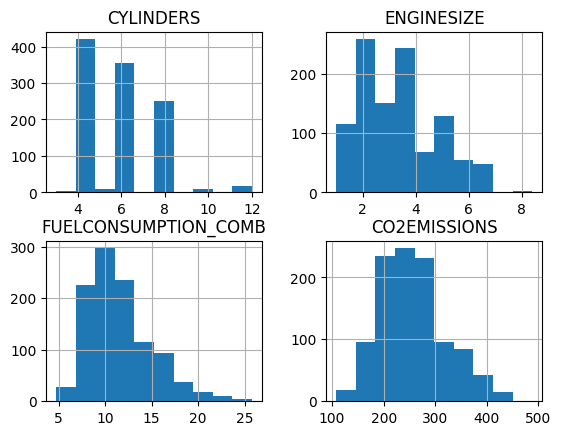

In [ ]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

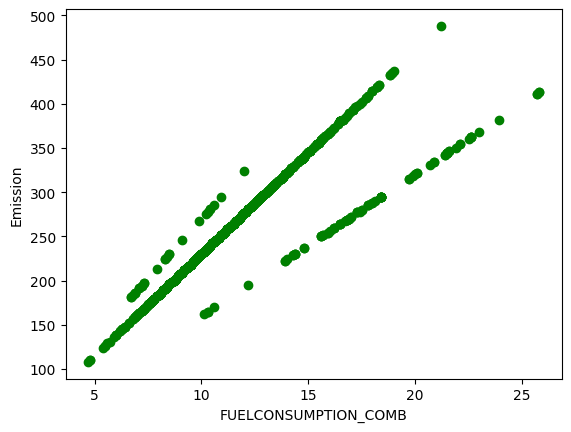

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='green')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

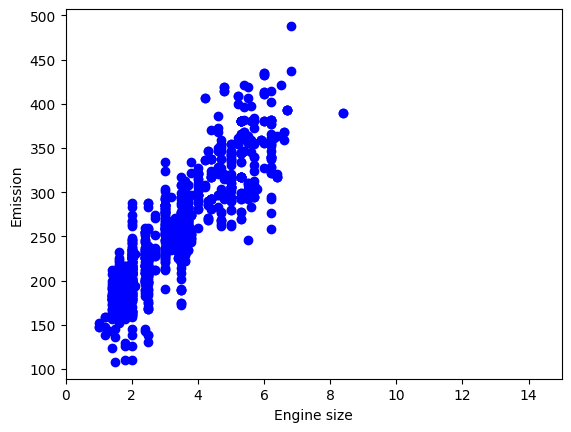

In [ ]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,15)
plt.show()

### Visualizando a Relação entre Cilindros e Emissão de CO2
*Análise para verificar se a relação entre o número de cilindros e a emissão é linear.*

**Practice exercise 1:**
1. Plot CYLINDER against CO2 Emission, to see how linear their relationship is.

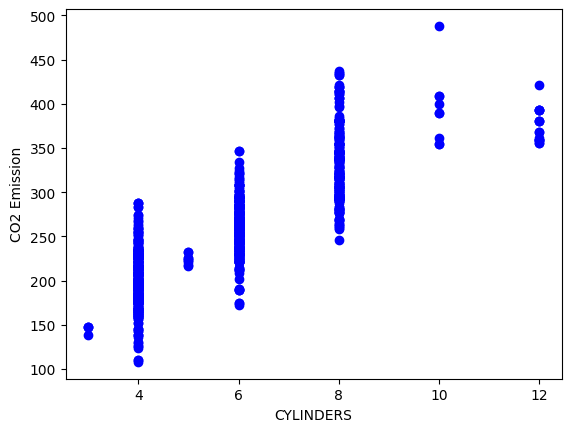

In [ ]:
 plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2 Emission")
plt.show()

In [ ]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (853,), (853,))

In [ ]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


In [ ]:
!pip install scikit-learn


Text(0, 0.5, 'Emission')

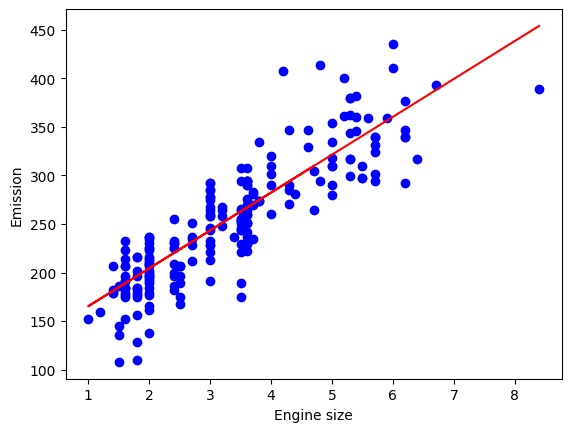

In [ ]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


# Practice exercises

1. *Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.*

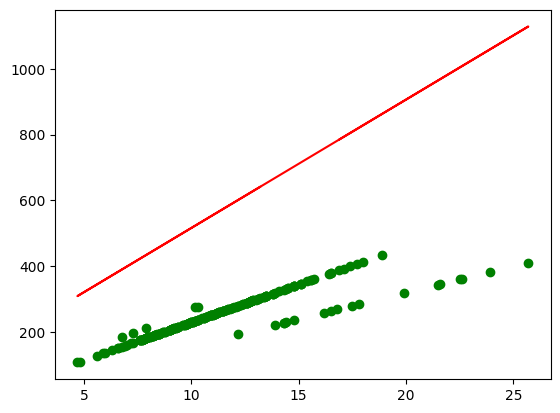

In [ ]:
plt.scatter(X_test, y_test, color='green')
plt.plot(X_test, regressor.coef_[0] * X_test + regressor.intercept_, '-r')
plt.show()

*2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets.*

In [ ]:
X = cdf[['FUELCONSUMPTION_COMB']]
y = cdf[['CO2EMISSIONS']]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


3. *Train a linear regression model using the training data you created.*

In [ ]:
X = cdf[['CYLINDERS']]
y = cdf[['CO2EMISSIONS']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred= regr.predict(X_test)

5. *Calculate and print the Mean Squared Error of the test predictions.*

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predição
y_pred = regr.predict(X_test)

# Métricas
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2-Score: {r2_score(y_test, y_pred):.2f}")

MAE: 25.71
MSE: 1109.35
RMSE: 33.31
R2-Score: 0.73
